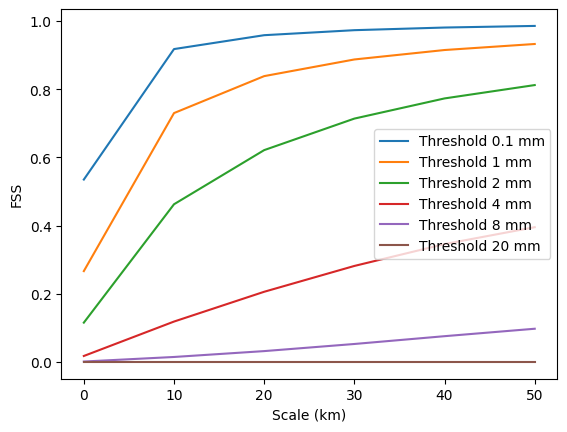

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex61_onestepdiffusion_dividemax_minmaxnormlazie_timesteps250_l2_droptop_0.5_150epoch/corrected_prcp_downs_global.nc")

# 提取数据
y_pred_np = ds['fcst_corrected'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()

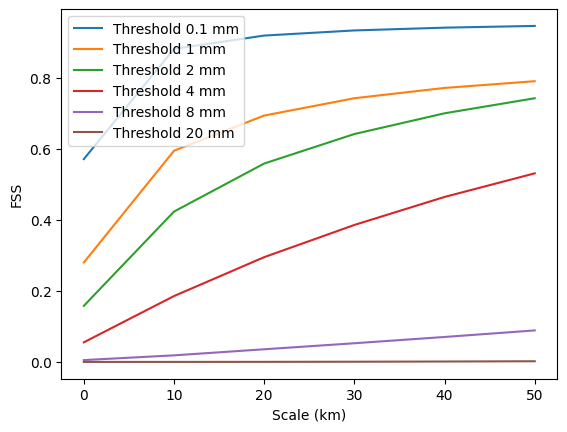

In [5]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

# 加载数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex4_onestep_weightmae_0.005/prcp_downs_unet_year_2020.nc")

# 提取数据
y_pred_np = ds['fcst'].values
tar_np = ds['hr'].values

tar_np = tar_np.reshape(tar_np.shape[1],-1)
y_pred_np = y_pred_np.reshape(y_pred_np.shape[1],-1)

# 定义阈值和scales
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 计算FSS
fss_scores = {thresh: [] for thresh in thresholds}
for radius in radii:
    for thresh in thresholds:
        fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
        fss_scores[thresh].append(fss_value)

# 绘图
fig, ax = plt.subplots()
for thresh in thresholds:
    ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')
ax.set_xlabel('Scale (km)')
ax.set_ylabel('FSS')
ax.legend()
plt.show()

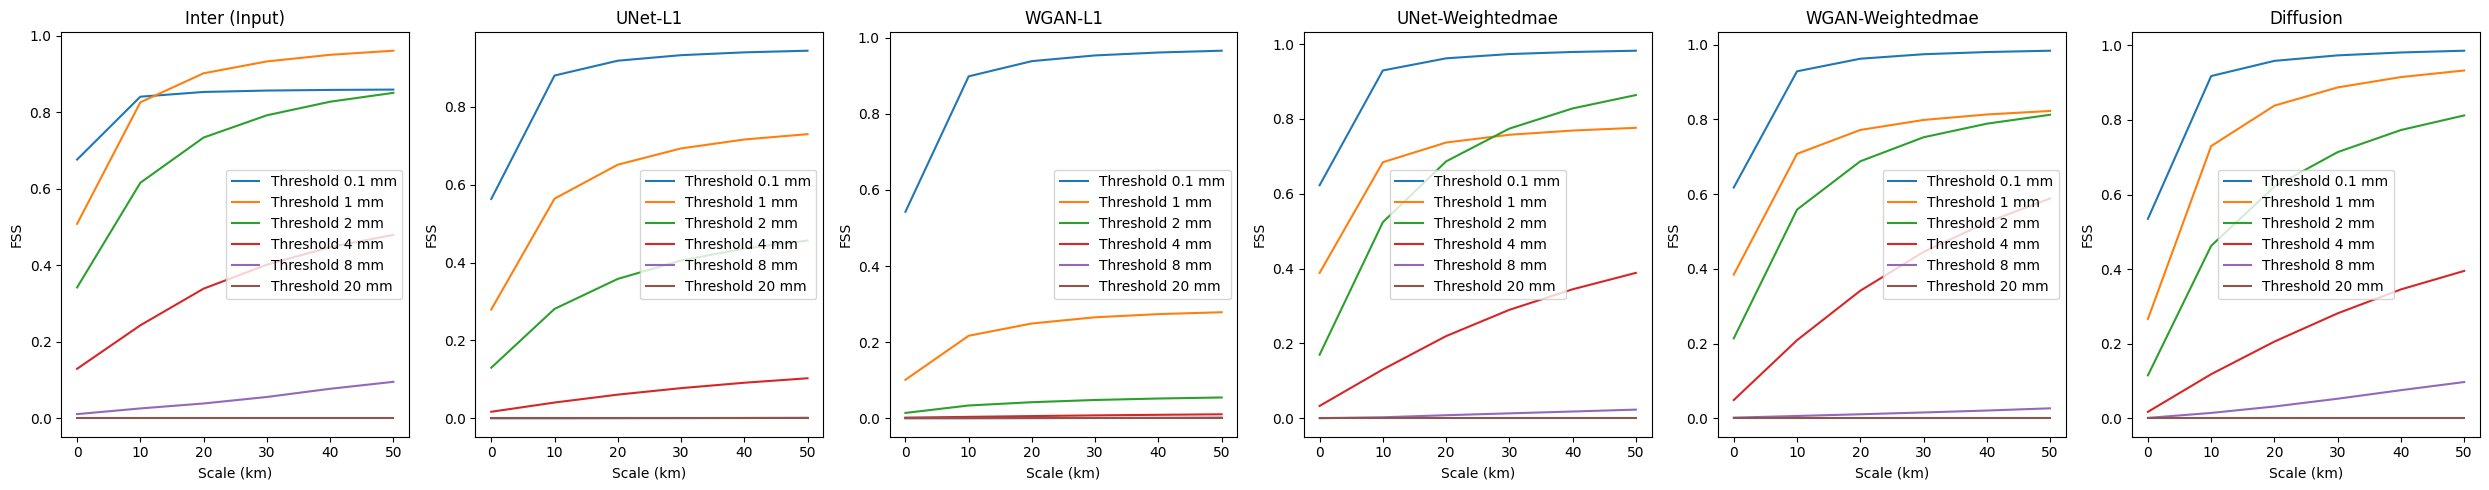

In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss

""""
ds_l1_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_4_onestep_l1_nofc_aheadtop_10/prcp_downs_unet_year_2020.nc")
ds_l1_wgan = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_3_onestepwgan_cri5_181_025_l1_aheadtop_10_180epoch/prcp_downs_wgan_year_2020.nc")
ds_weightedmae_wgan = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_onestepwgan_cri5_181_025_weightmae_aheadtop_0.008_130epoch/prcp_downs_wgan_year_2020.nc")
ds_weightedmae_unet = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex14_onestep_weightmae_aheadtop_0.008/prcp_downs_unet_year_2020.nc")
ds_diffusion = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex61_onestepdiffusion_dividemax_minmaxnormlazie_timesteps250_l2_droptop_0.5_150epoch/corrected_prcp_downs_global.nc")
"""

models = {
    "Inter (Input)": "/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_3_onestepwgan_cri5_181_025_l1_aheadtop_10_180epoch/prcp_downs_wgan_year_2020.nc", 
    "UNet-L1": "/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_4_onestep_l1_nofc_aheadtop_10/prcp_downs_unet_year_2020.nc",  
    "WGAN-L1": "/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_3_onestepwgan_cri5_181_025_l1_aheadtop_10_180epoch/prcp_downs_wgan_year_2020.nc", 
    "UNet-Weightedmae": "/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex14_onestep_weightmae_aheadtop_0.008/prcp_downs_unet_year_2020.nc",  
    "WGAN-Weightedmae": "/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_onestepwgan_cri5_181_025_weightmae_aheadtop_0.008_130epoch/prcp_downs_wgan_year_2020.nc",  
    "Diffusion": "/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex61_onestepdiffusion_dividemax_minmaxnormlazie_timesteps250_l2_droptop_0.5_150epoch/corrected_prcp_downs_global.nc", 
}

# 阈值和尺度
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

fig, axes = plt.subplots(1, 6, figsize=(25, 5))

# 遍历模型，计算FSS并绘图
for i, (model_name, model_path) in enumerate(models.items()):
    # 加载数据集
    ds = xr.open_dataset(model_path)

    # 根据模型名称选择不同的输入数据变量
    if model_name == "Inter (Input)":
        y_pred_np = ds['inter'].values  # 输入数据 (预测值)
    elif model_name == "Diffusion":
        y_pred_np = ds['fcst_corrected'].values  # 输入数据 (预测值)
    else:
        y_pred_np = ds['fcst'].values  # 默认输入数据 (预测值)

    tar_np = ds['hr'].values  # 目标数据 (实际值)

    # 重新调整数据形状
    tar_np = tar_np.reshape(tar_np.shape[1], -1)
    y_pred_np = y_pred_np.reshape(y_pred_np.shape[1], -1)

    # 计算FSS
    fss_scores = {thresh: [] for thresh in thresholds}
    for radius in radii:
        for thresh in thresholds:
            fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
            fss_scores[thresh].append(fss_value)

    # 获取当前的子图
    ax = axes[i]

    # 绘制FSS曲线
    for thresh in thresholds:
        ax.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')

    # 设置标题和标签
    ax.set_title(model_name)
    ax.set_xlabel('Scale (km)')
    ax.set_ylabel('FSS')
    ax.legend()

# 调整布局
plt.tight_layout()
plt.show()


In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pysteps.verification.spatialscores import fss
import os  # 导入os模块用于创建文件夹

models = {
    "Inter (Input)": "/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_3_onestepwgan_cri5_181_025_l1_aheadtop_10_180epoch/prcp_downs_wgan_year_2020.nc", 
    "UNet-L1": "/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_4_onestep_l1_nofc_aheadtop_10/prcp_downs_unet_year_2020.nc",  
    "WGAN-L1": "/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_3_onestepwgan_cri5_181_025_l1_aheadtop_10_180epoch/prcp_downs_wgan_year_2020.nc", 
    "UNet-Weightedmae": "/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex14_onestep_weightmae_aheadtop_0.008/prcp_downs_unet_year_2020.nc",  
    "WGAN-Weightedmae": "/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_onestepwgan_cri5_181_025_weightmae_aheadtop_0.008_130epoch/prcp_downs_wgan_year_2020.nc",  
    "Diffusion": "/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex61_onestepdiffusion_dividemax_minmaxnormlazie_timesteps250_l2_droptop_0.5_150epoch/corrected_prcp_downs_global.nc", 
}

# 创建保存图像的文件夹
output_dir = "FSS_Plots"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 阈值和尺度
thresholds = [0.1, 1, 2, 4, 8, 20]
radii = [0, 10, 20, 30, 40, 50]

# 遍历模型，计算FSS并绘图
for model_name, model_path in models.items():
    # 加载数据集
    ds = xr.open_dataset(model_path)

    # 根据模型名称选择不同的输入数据变量
    if model_name == "Inter (Input)":
        y_pred_np = ds['inter'].values  # 输入数据 (预测值)
    elif model_name == "Diffusion":
        y_pred_np = ds['fcst_corrected'].values  # 输入数据 (预测值)
    else:
        y_pred_np = ds['fcst'].values  # 默认输入数据 (预测值)

    tar_np = ds['hr'].values  # 目标数据 (实际值)

    # 重新调整数据形状
    tar_np = tar_np.reshape(tar_np.shape[1], -1)
    y_pred_np = y_pred_np.reshape(y_pred_np.shape[1], -1)

    # 计算FSS
    fss_scores = {thresh: [] for thresh in thresholds}
    for radius in radii:
        for thresh in thresholds:
            fss_value = fss(y_pred_np, tar_np, thresh, scale=radius)
            fss_scores[thresh].append(fss_value)

    # 绘制单独的图
    plt.figure(figsize=(8, 6))

    for thresh in thresholds:
        plt.plot(radii, fss_scores[thresh], label=f'Threshold {thresh} mm')

    # 设置标题和标签
    plt.title(model_name)
    plt.xlabel('Scale (km)')
    plt.ylabel('FSS')
    plt.legend()
    plt.grid(True)

    # 保存图像到指定文件夹
    plt.savefig(os.path.join(output_dir, f"FSS_{model_name}.png"), dpi=300)
    plt.close()

print(f"所有图像已保存在 {output_dir} 文件夹中！")


Pysteps configuration file found at: /cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/yinzunyi/py3.9/lib/python3.9/site-packages/pysteps/pystepsrc

所有图像已保存在 FSS_Plots 文件夹中！
